In [25]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import uncertainties as un
from glob import glob
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

from vtools.XRD import read_xrd, calc_vat_frac, fit_peak, pkfn, pkfn_nobkg, plot_fit

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Step 1: Calibrate XRD Phase Determination

Measured a mixture of two powders:
 - $P_1$: the vaterite seed, containing a mixture of vaterite (~95%) and calcite (~5%)
 - $P_2$: pure calcite

Determine the intensity ratio of the main vaterite ($I_v$) and calcite ($I_c$) peaks, $\frac{I_v}{I_c}$, which is linearly related to the fractional mass abundance of vaterite in the powder:
$$
\frac{I_v}{I_c} = a \frac{M_v}{M_c}  \\
$$
...but we don't know $M_v$ - we only know the mass of the seed $M_s$, which contains both vaterite and calcite following:
$$
f = \frac{M_v^{seed}}{M_v^{seed} + M_v^{seed}}\\
M_v^{seed} = f M_s \\
M_c^{seed} = (1 - f) M_s \\
$$
where $f$ is the unknown fractional abundance of vaterite in the seed. From this:

$$
\frac{I_v}{I_c} = a \frac{f M_s}{M_c + (1 - f) M_s}
$$


We therefore have two unknowns, $f$ and $a$, which can be determined by fitting the data. 

In [26]:
fs = glob('data/raw_xrd/cal_*.txt')
patterns = {}
for f in fs:
    fname = f.split('/')[-1].split('.')[0]
    dat = read_xrd(f)
    dat.columns = dat.columns.str.strip()
    patterns[fname] = dat

In [27]:
# define approximate peak positions and 2theta window
cal_2theta = 13.55
vat_2theta = 12.5
window = 0.5

order = ['cal_0_calcite_100_seed', 'cal_25_calcite_75_seed', 'cal_50_calcite_50_seed', 'cal_75_calcite_25_seed', 'cal_100_calcite_0_seed']

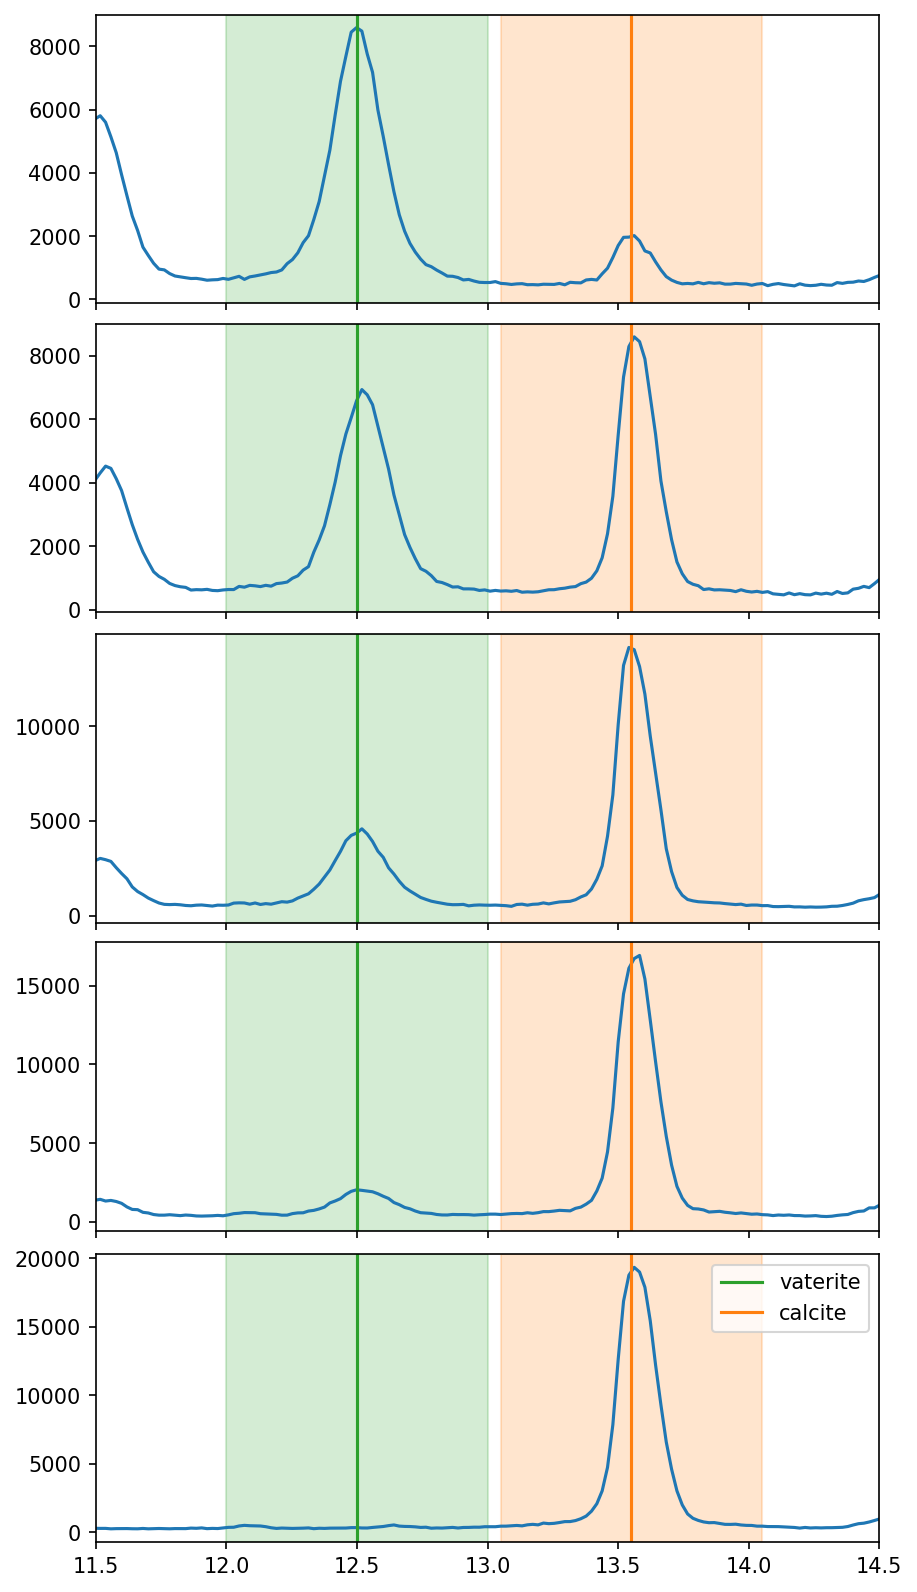

In [28]:
fig, axs = plt.subplots(len(patterns), 1, figsize=[6, len(patterns) * 2.1], sharex=True, constrained_layout=True)

for ax, key in zip(axs, order):
    dat = patterns[key]
    ax.plot(dat.Angle, dat.PSD)
    ax.set_xlim(11.5, 14.5)
    
    ax.axvline(vat_2theta, color='C2', label='vaterite')
    ax.axvspan(vat_2theta - window, vat_2theta + window, color='C2', alpha=0.2)
    
    ax.axvline(cal_2theta, color='C1', label='calcite')
    ax.axvspan(cal_2theta - window, cal_2theta + window, color='C1', alpha=0.2)
axs[-1].legend()

In [29]:
# fit peaks
vat_fits = {}
cal_fits = {}
for k, dat in patterns.items():
    vat_fits[k] = fit_peak(dat, vat_2theta, window)
    cal_fits[k] = fit_peak(dat, cal_2theta, window)

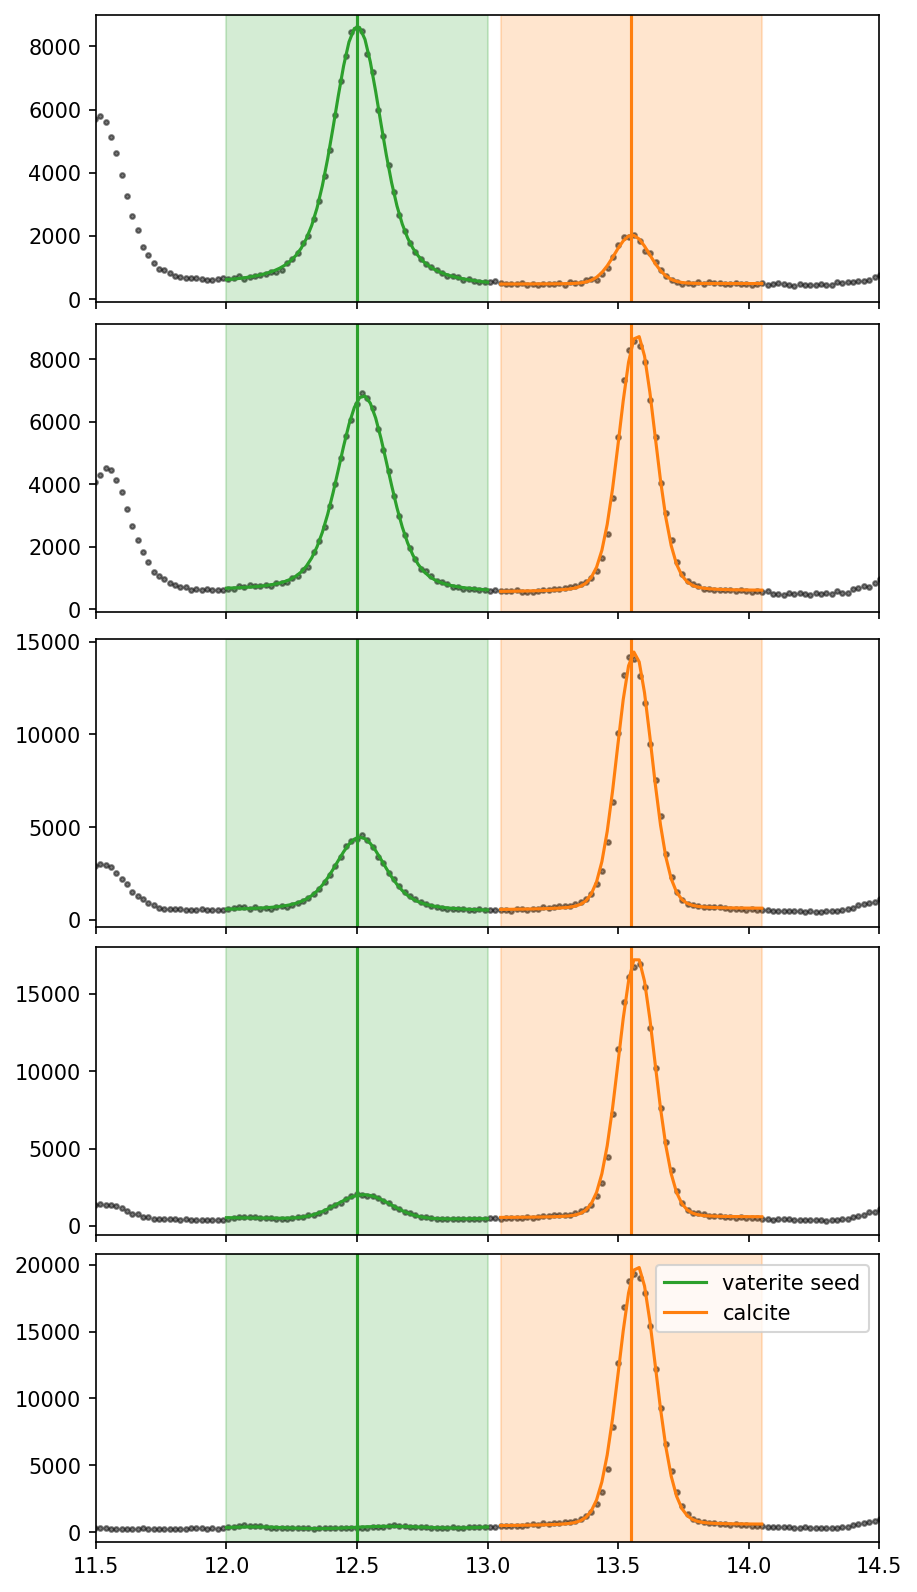

In [30]:
fig, axs = plt.subplots(len(patterns), 1, figsize=[6, len(patterns) * 2.1], sharex=True, constrained_layout=True)

for ax, k in zip(axs, order):
    dat = patterns[k]
    ax.scatter(dat.Angle, dat.PSD, s=5, color=(0,0,0,0.5))
    ax.set_xlim(11.5, 14.5)
    
    ax.axvline(vat_2theta, color='C2', label='vaterite seed')
    ax.axvspan(vat_2theta - window, vat_2theta + window, color='C2', alpha=0.2)
    
    xn = np.linspace(vat_2theta - window, vat_2theta + window)
    ax.plot(xn, pkfn(xn, *vat_fits[k][0]), color='C2')
    
    ax.axvline(cal_2theta, color='C1', label='calcite')
    ax.axvspan(cal_2theta - window, cal_2theta + window, color='C1', alpha=0.2)
    
    xn = np.linspace(cal_2theta - window, cal_2theta + window)
    ax.plot(xn, pkfn(xn, *cal_fits[k][0]), color='C1')
    
axs[-1].legend()

In [32]:
# calculate areas
vat_areas = {}
for k, (p, cov) in vat_fits.items():
    xn = np.linspace(vat_2theta - window, vat_2theta + window)
    yn = pkfn_nobkg(xn, *p)
    vat_areas[k] = np.trapezoid(yn, xn)

vat_areas['100_calcite_0_vaterite'] = 0
    
cal_areas = {}
for k, (p, cov) in cal_fits.items():
    xn = np.linspace(cal_2theta - window, cal_2theta + window)
    yn = pkfn_nobkg(xn, *p)
    cal_areas[k] = np.trapezoid(yn, xn)

In [33]:
# load weight data
dat = pd.read_csv('data/XRD_calcite_seed_mixtures.csv')

# calculate fractional abundance and ratio of phase weights
dat['F_seed'] = dat.mg_seed / (dat.mg_seed + dat.mg_calcite)
dat['R_seed'] = dat.mg_seed / dat.mg_calcite

# Assign peak areas
for i, k in enumerate(order[::-1]):
    dat.loc[i, 'A_C104'] = cal_areas[k]
    dat.loc[i, 'A_V101'] = vat_areas[k]
    
# calculate peak area ratio
dat['R_Areas'] = dat.A_V101 / dat.A_C104
    
dat

,mg_calcite,mg_seed,F_seed,R_seed,A_C104,A_V101,R_Areas
0,20.00,0.00,0.000000,0.000000,3514.111512,0.037562,0.000011
1,15.00,4.84,0.243952,0.322667,2983.617598,351.502166,0.117811
2,10.11,10.62,0.512301,1.050445,2389.952635,1080.611077,0.452147
3,4.96,14.90,0.750252,3.004032,1470.475908,1687.621024,1.147670
4,0.00,20.39,1.000000,inf,264.972122,2238.918972,8.449640


Text(0, 0.5, 'seed / calcite (peak area)')

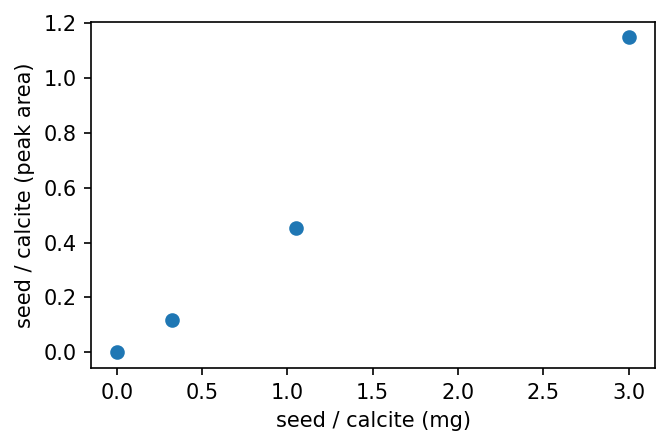

In [34]:
plt.scatter(dat.R_seed, dat.R_Areas)
plt.xlabel('seed / calcite (mg)')
plt.ylabel('seed / calcite (peak area)')

### Determine $f$ and $a$

In [35]:
# NB using fractional abundance of seed, as it's more convenient
def fitfn(F_seed, f, a):
    return a * (F_seed * f) / ((1 - F_seed) + (1 - f) * F_seed)

p, cov = curve_fit(fitfn, dat.F_seed, dat.R_Areas, p0=(0.95, 8/100))

# package fit uncertainties.
up = un.correlated_values(p, cov)

print(f'f: {p[0]:.3f}\na: {p[1]:.3f}')

f: 0.948
a: 0.467


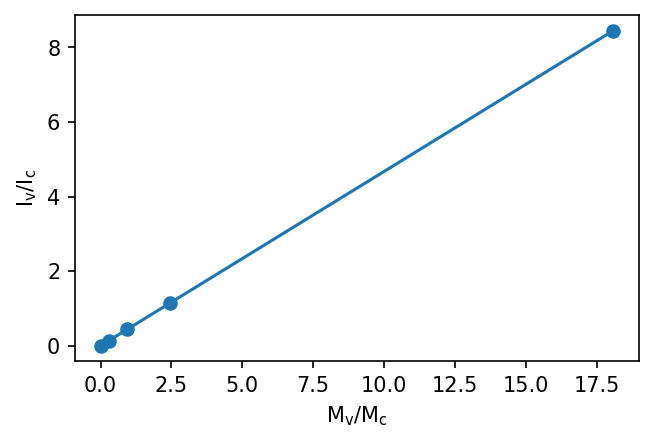

In [36]:
f = p[0]
RM = (dat.F_seed * f) / ((1 - dat.F_seed) + (1 - f) * dat.F_seed)
plt.scatter(RM, dat.A_V101 / dat.A_C104)

plt.xlabel('$M_v / M_c$')
plt.ylabel('$I_v / I_c$')

xn = np.linspace(0, 18)
plt.plot(xn, xn * p[1]);

In [37]:
f, a = up

print(f'Seed Vaterite: {f:.3f}\nSlope: {a:.3f}')

Seed Vaterite: 0.948+/-0.001
Slope: 0.467+/-0.007


## Step 2: Apply calibration to Unknowns

In [38]:
fs = sorted([f for f in glob('data/raw_xrd/*.txt') if 'cal_' not in f and 'vaterite_' not in f])

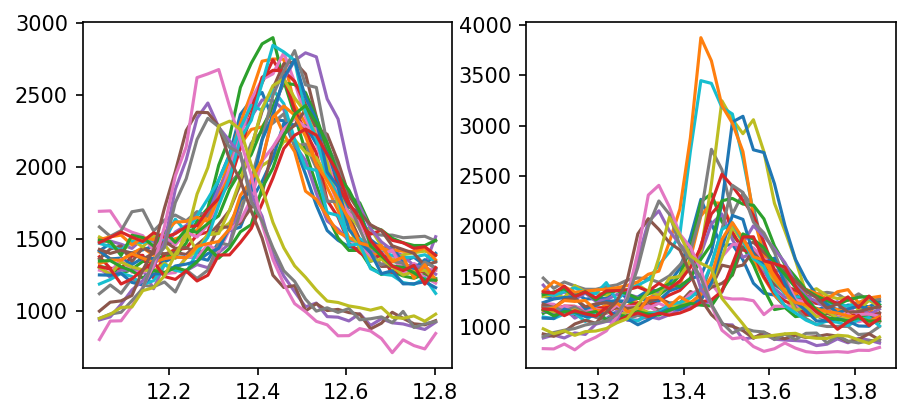

In [39]:
# check peak position and window
vat_location = 12.42
cal_location = 13.47
window = 0.4

locs = [vat_location, cal_location]

fig, axs = plt.subplots(1, 2, figsize=[7, 3])
for f in fs:
    dat = read_xrd(f)
    for ax, loc in zip(axs, locs):
        ind = (dat.Angle >= loc - window) & (dat.Angle <= loc + window)
        ax.plot(dat.Angle[ind], dat.PSD[ind])

/home/oscar/GitHub/prepub_supplementary/supplements/vaterite_geochem/vtools/XRD.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  def read_xrd(file):


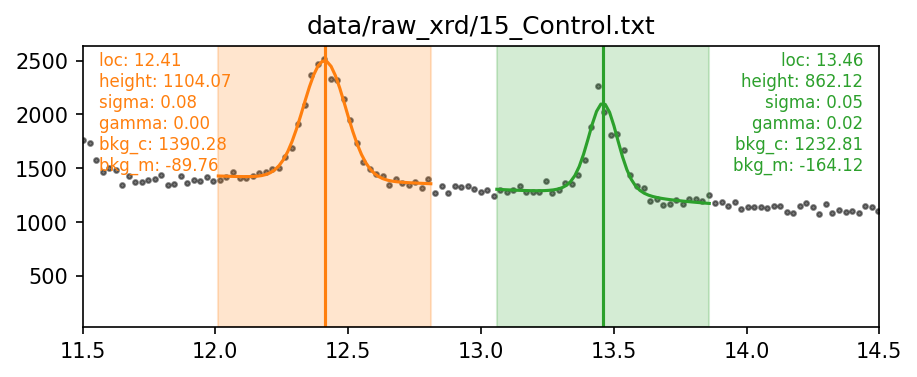

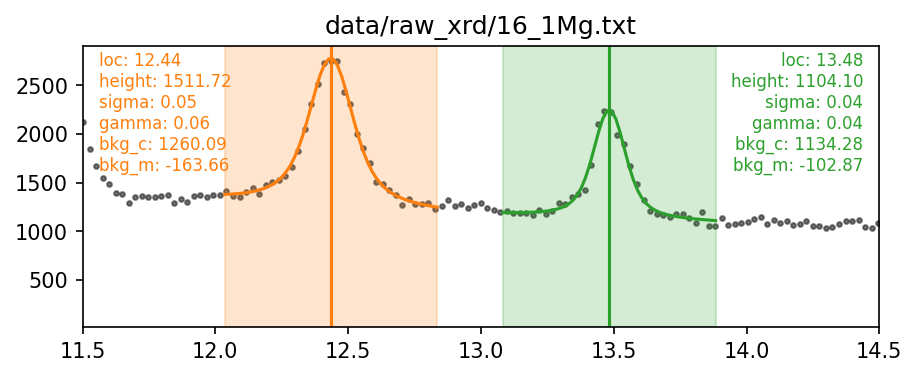

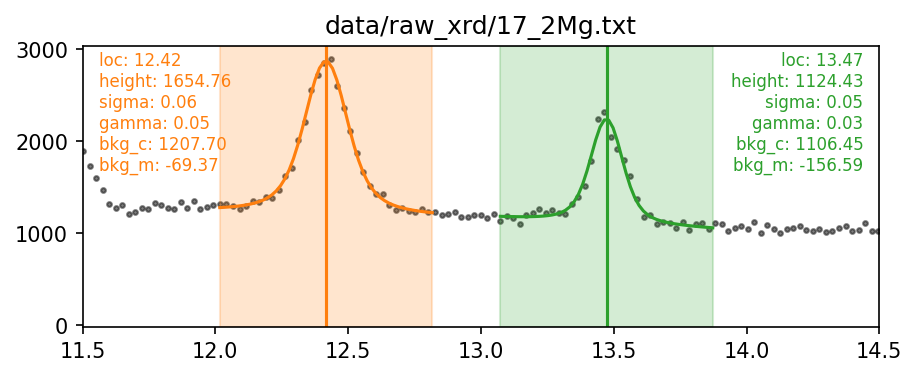

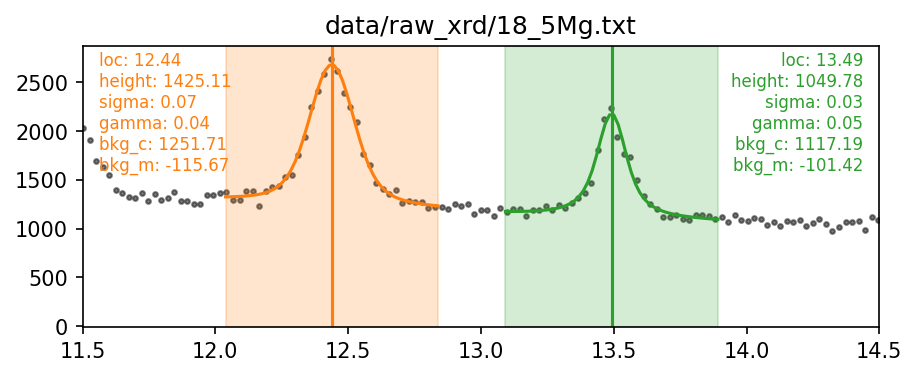

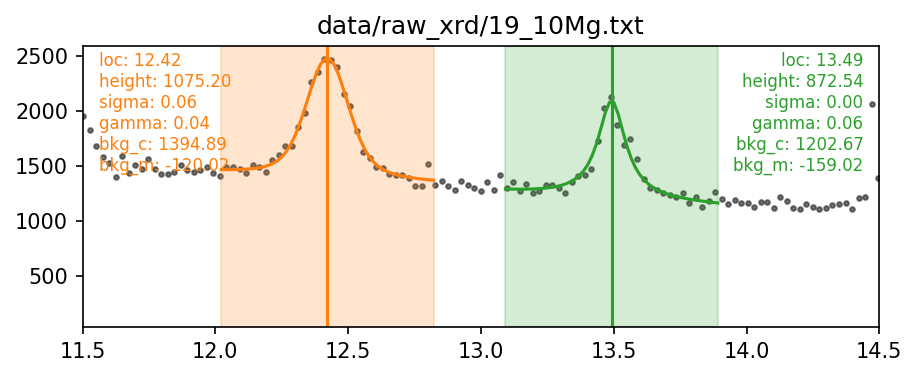

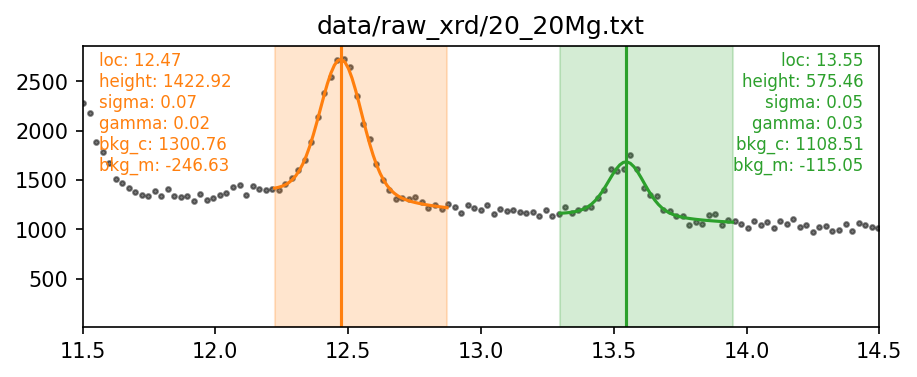

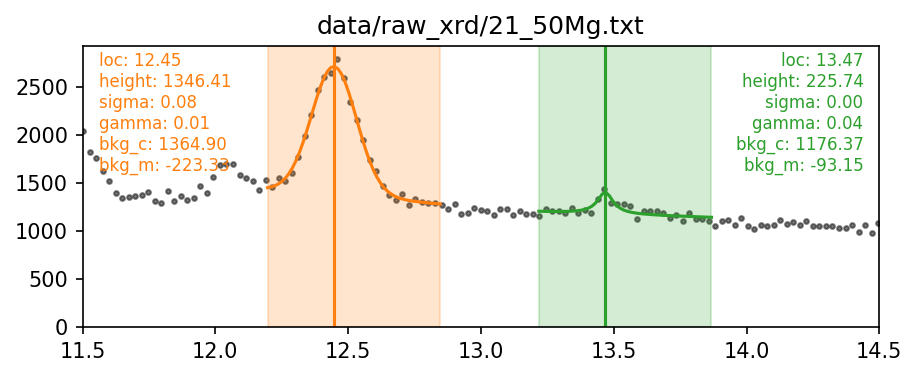

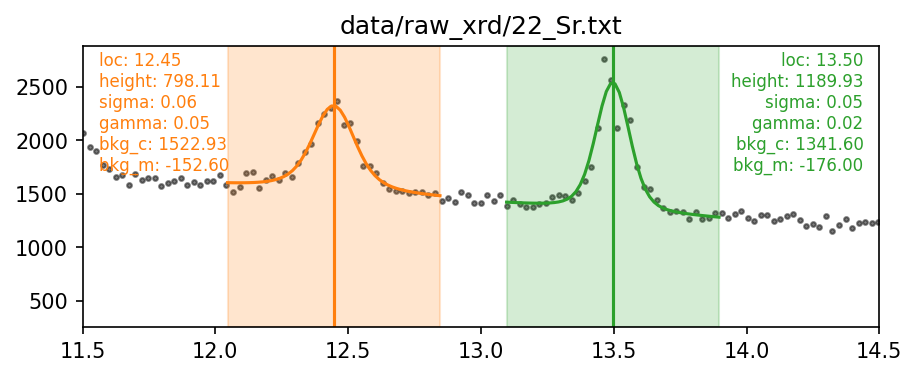

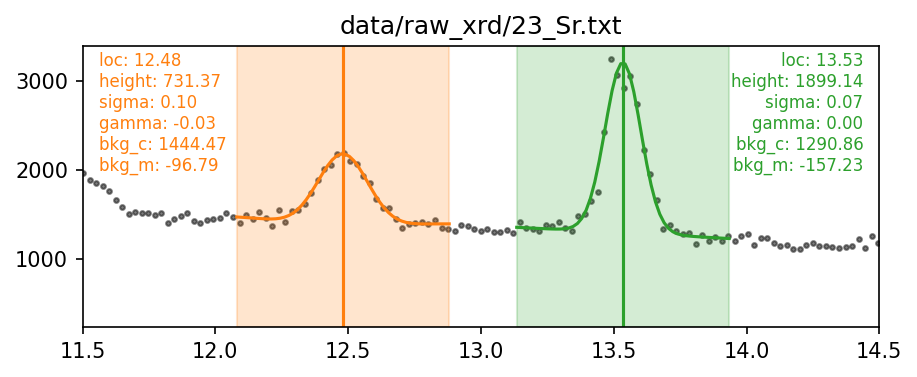

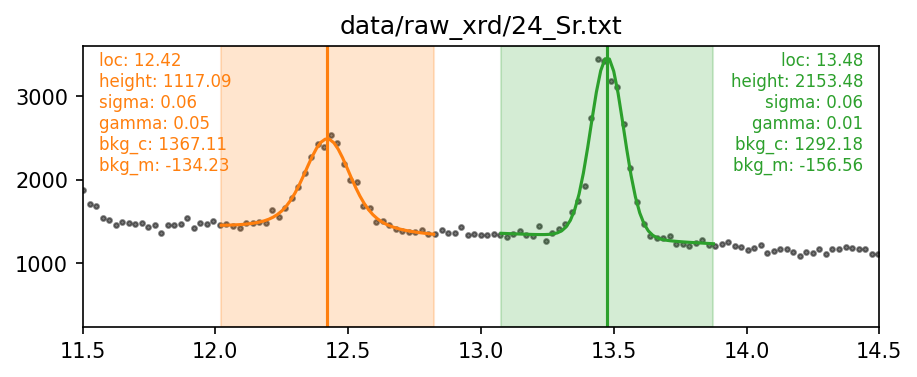

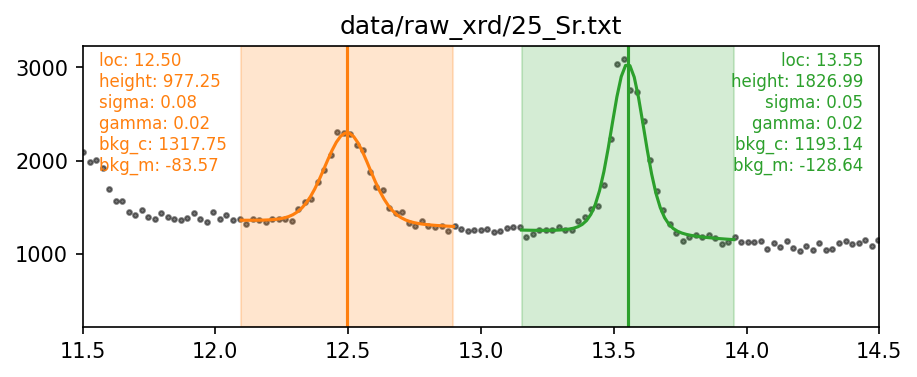

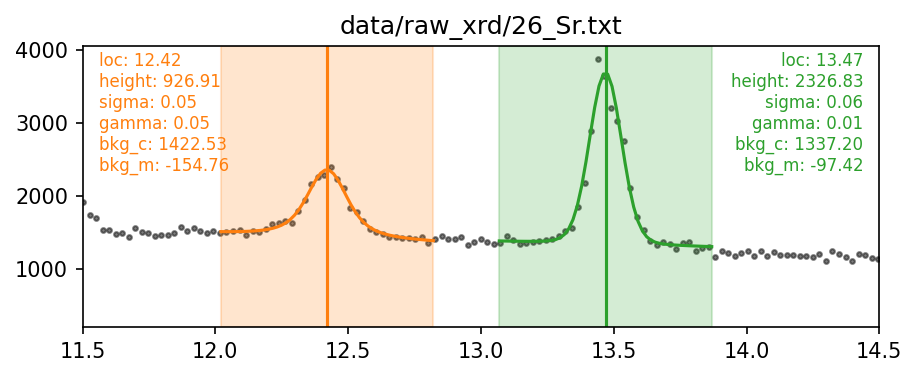

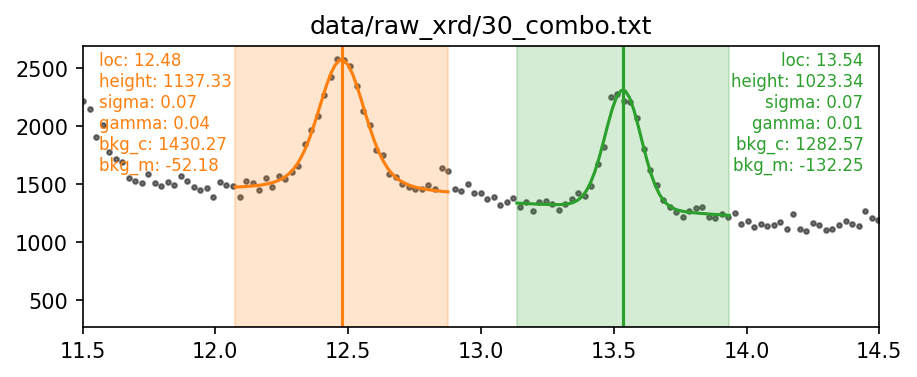

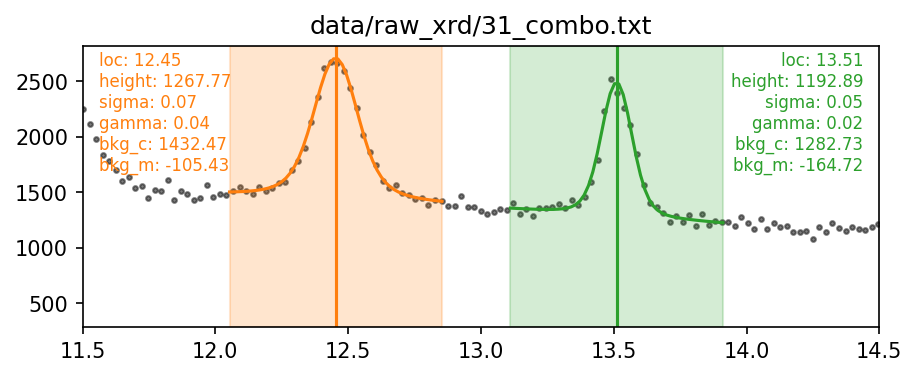

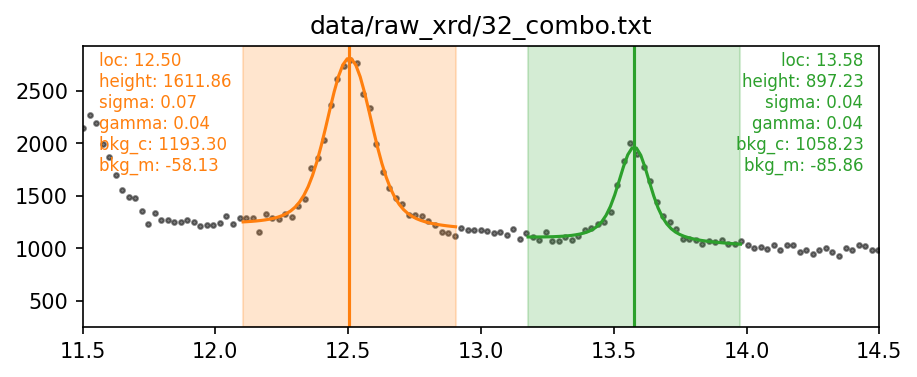

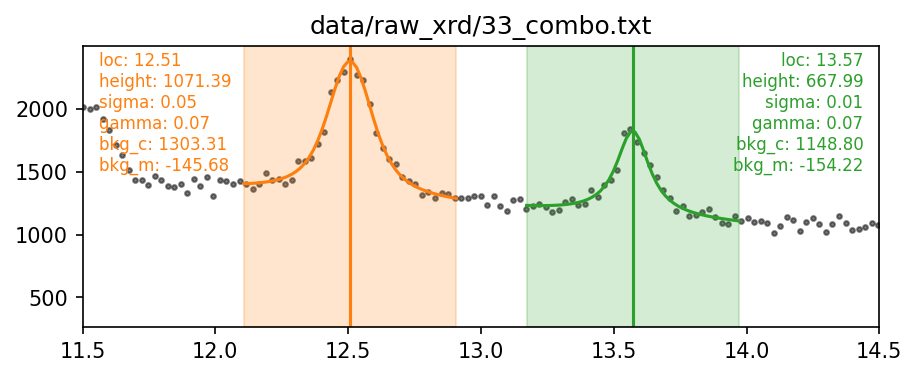

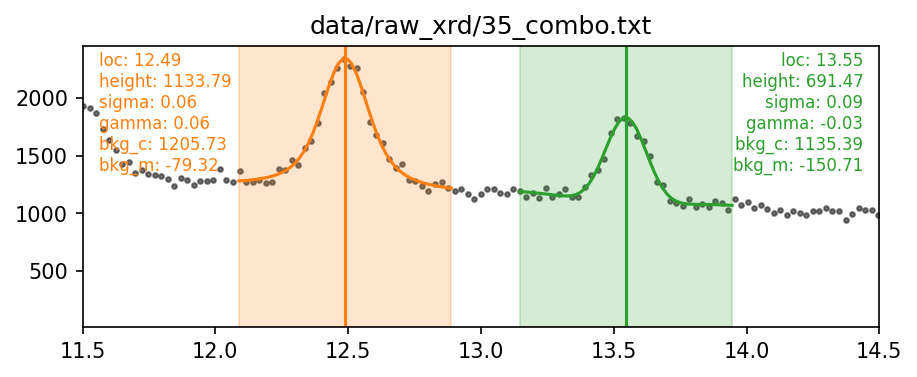

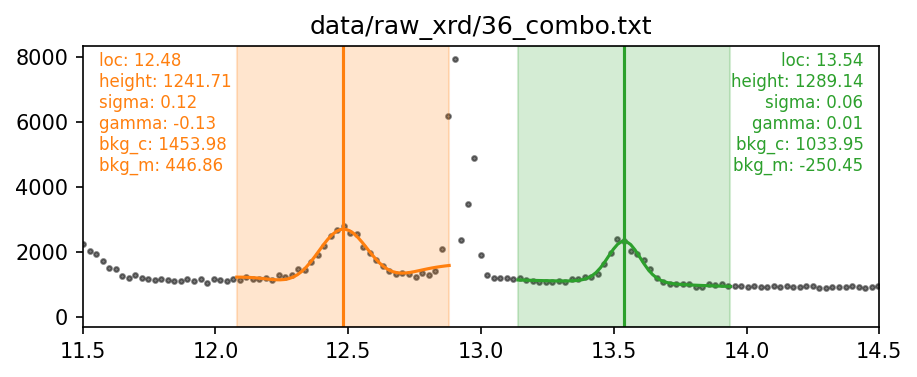

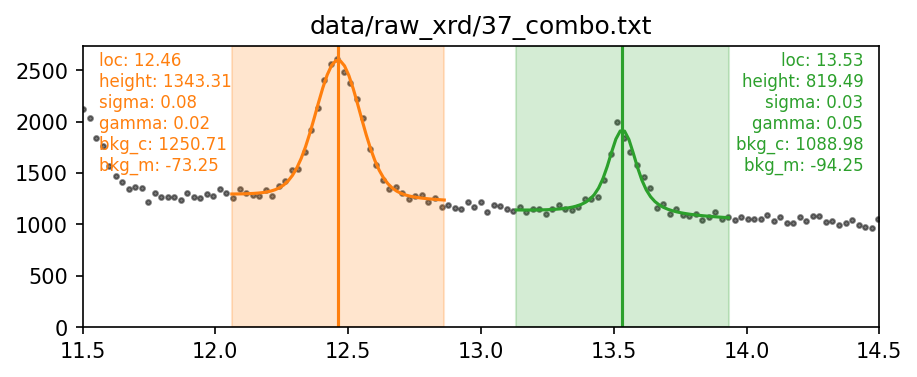

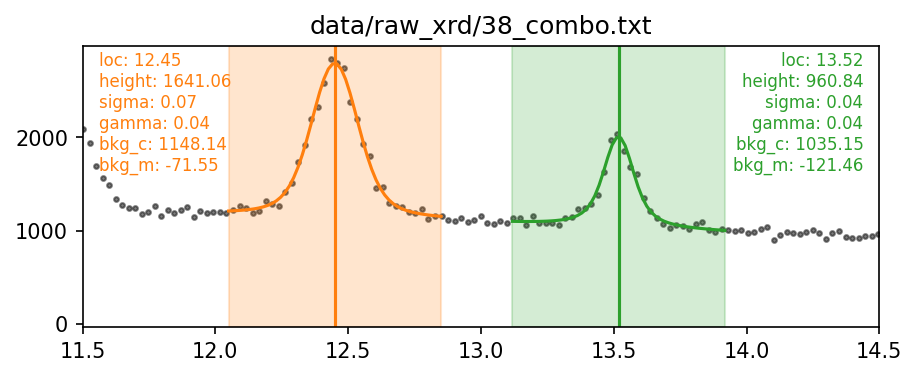

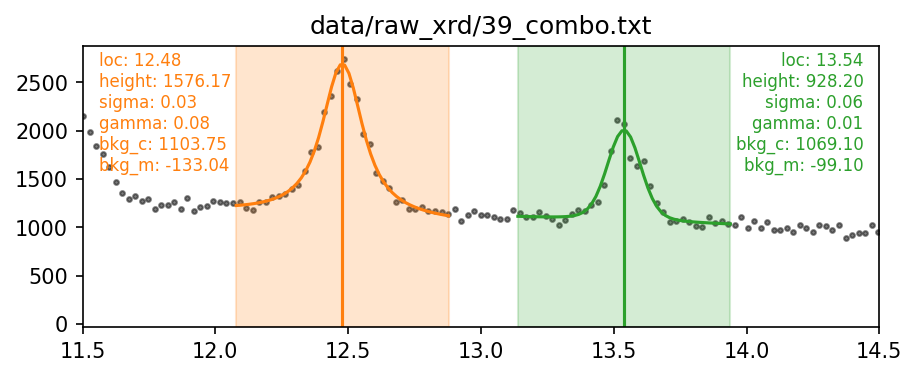

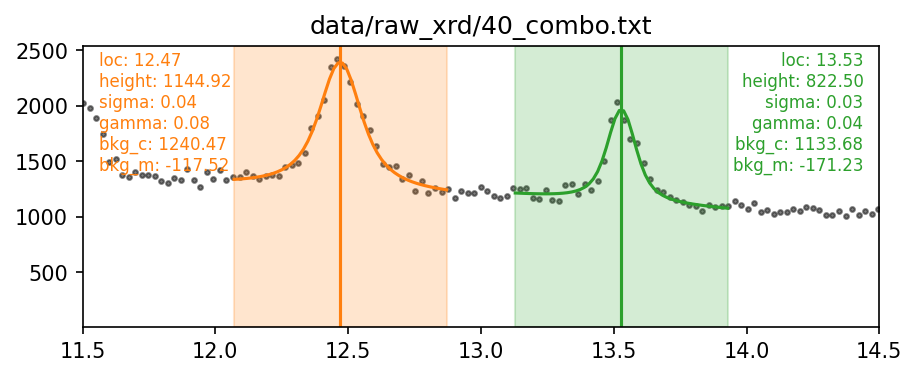

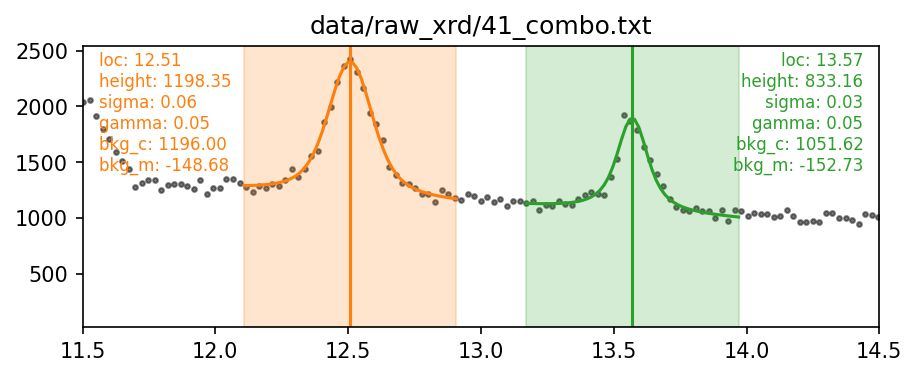

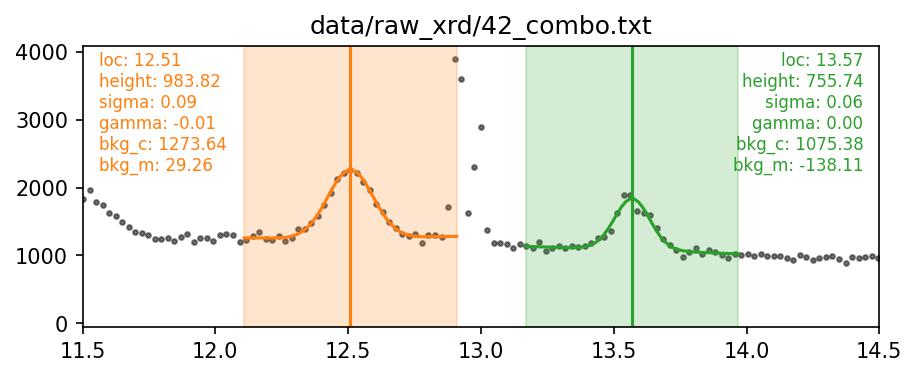

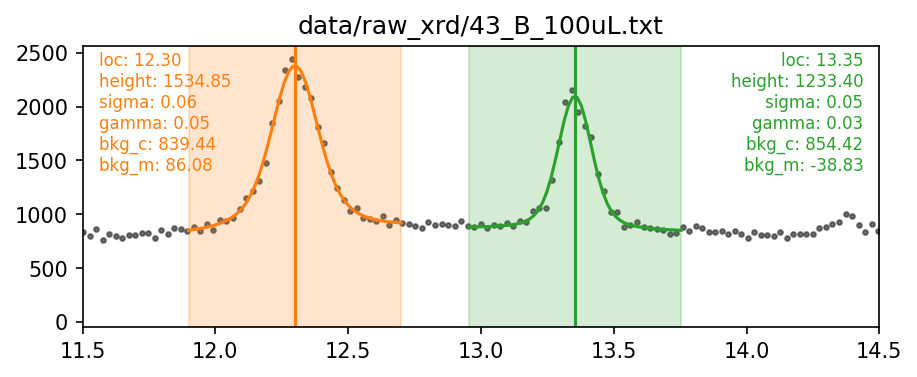

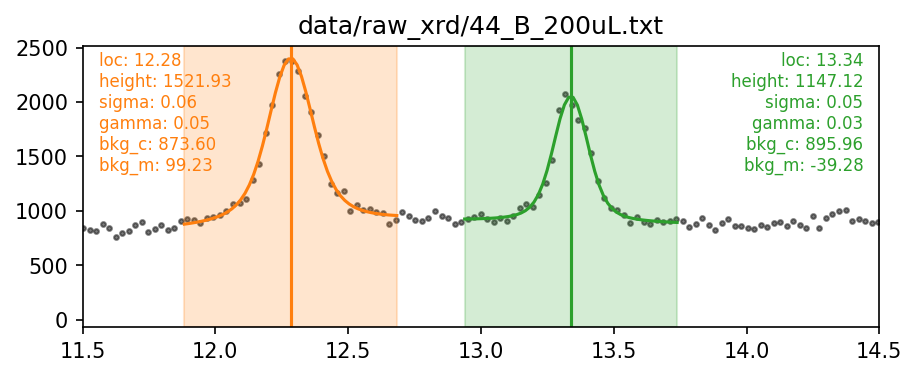

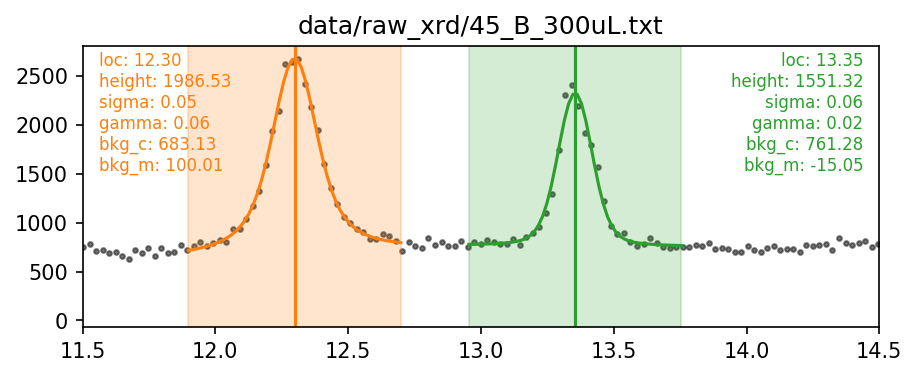

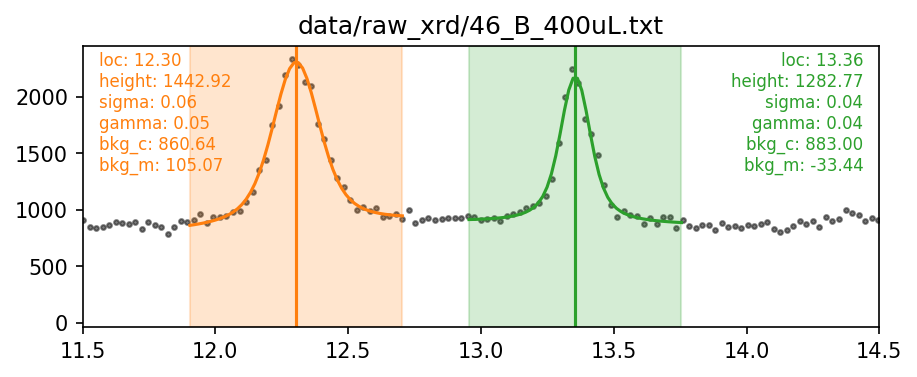

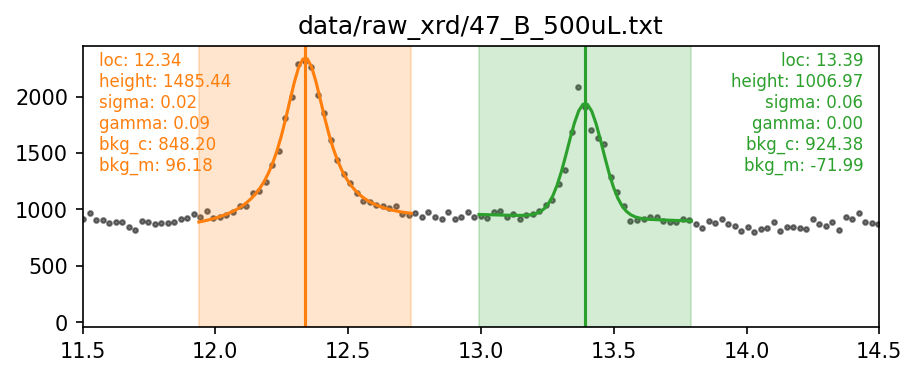

In [44]:

out = pd.DataFrame(columns=['fV'])

smallwin = [20, 21]

for f in fs:
    exp = int(os.path.basename(f).split('_')[0])
    frac = None
    if exp in smallwin:
        win_left = 0.25
        win_right = 0.4
    else:
        win_left = 0.4
        win_right = 0.4
    while frac is None and win_left > 0:
        try:
            frac = calc_vat_frac(f, win_left=win_left, win_right=win_right, a=a)
        except:
            win_left -= 0.05
            win_right -= 0.05
    out.loc[exp, 'fV'] = frac
    fig, ax = plot_fit(f, vat_location=vat_location, cal_location=cal_location, win_left=win_left, win_right=win_right)
    ax.set_title(f)
out.sort_index(inplace=True)

In [45]:
out.to_pickle('data/precipitate_mineralogy.pkl')